# Flux Matching — Quickstart

This notebook shows the minimal setup for training a generative model with `flux_matching_loss`.

**Three steps:**
1. Define a model `f_theta(x)` that is a vector valued function
2. Call `flux_matching_loss(f_theta, x, sigma2)` in your training loop
3. Sample with Langevin dynamics

That's it.

In [82]:
import sys
sys.path.insert(0, '..')

import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from src.loss import flux_matching_loss

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

device: cuda


## 1. Data

We use a 2D ring as the target distribution.

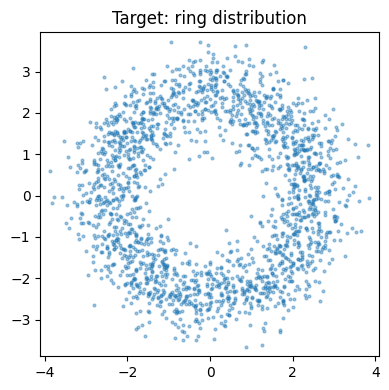

In [83]:
RING_RADIUS = 2.5
RING_WIDTH  = 0.5

def sample_ring(n: int) -> torch.Tensor:
    theta = 2 * torch.pi * torch.rand(n, device=DEVICE)
    r     = RING_RADIUS + RING_WIDTH * torch.randn(n, device=DEVICE)
    return torch.stack([r * torch.cos(theta), r * torch.sin(theta)], dim=-1)

data = sample_ring(2000).cpu()
plt.figure(figsize=(4, 4))
plt.scatter(data[:, 0], data[:, 1], s=4, alpha=0.4)
plt.title('Target: ring distribution')
plt.axis('equal')
plt.tight_layout()
plt.show()

## 2. Define `f_theta`

`flux_matching_loss` expects a callable `f_theta(x)` that returns a vector field with the **same shape as `x`**.

In [84]:
f_theta = nn.Sequential(
    nn.Linear(2, 128), nn.SiLU(),
    nn.Linear(128, 128), nn.SiLU(),
    nn.Linear(128, 2),
).to(DEVICE)

## 3. Train

The loss takes `(f_theta, x, sigma2)` and returns per-sample losses `[B]`.
`sigma2` is the noise variance, which controls how smoothed the reference distribution is.

In [85]:
SIGMA2 = torch.tensor(0.05, device=DEVICE)
opt    = torch.optim.Adam(f_theta.parameters(), lr=1e-3)

for step in range(5000):
    x    = sample_ring(512)
    loss = flux_matching_loss(f_theta, x, SIGMA2).mean()
    opt.zero_grad()
    loss.backward()
    opt.step()
    if (step + 1) % 500 == 0:
        print(f'step {step+1:4d}  loss={loss.item():.4f}')

print("Training complete.")

step  500  loss=24.5845
step 1000  loss=9.9605
step 1500  loss=1.8439
step 2000  loss=40.7095
step 2500  loss=16.7201
step 3000  loss=4.4006
step 3500  loss=234.3497
step 4000  loss=601.3399
step 4500  loss=50.4494
step 5000  loss=193.5680
Training complete.


## 4. Sample with Langevin dynamics

Use `f_theta` directly as the drift:
$$x_{t+1} = x_t + \frac{\epsilon}{2}\, f_\theta(x_t) + \sqrt{\epsilon}\, \eta, \qquad \eta \sim \mathcal{N}(0, I)$$

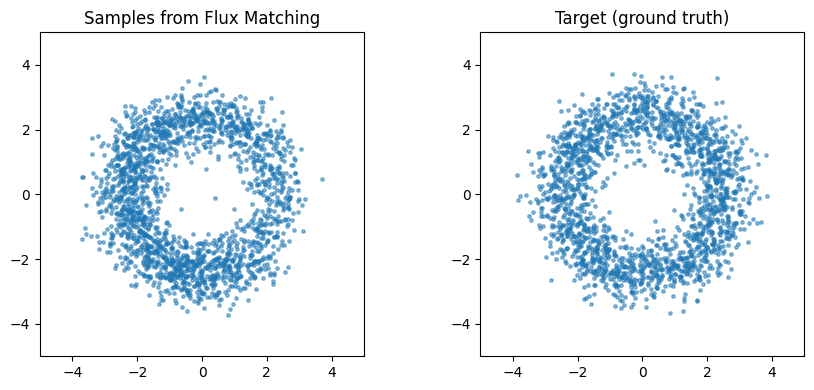

In [86]:
@torch.no_grad()
def langevin_sample(net, n=2000, steps=2000, step_size=0.01):
    x = torch.randn(n, 2, device=DEVICE)
    for _ in range(steps):
        x = x + 0.5 * step_size * net(x) + step_size ** 0.5 * torch.randn_like(x)
    return x.cpu()

samples = langevin_sample(f_theta)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, pts, title in zip(axes,
    [samples, data],
    ['Samples from Flux Matching', 'Target (ground truth)']):
    ax.scatter(pts[:, 0], pts[:, 1], s=6, alpha=0.5)
    ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
    ax.set_aspect('equal'); ax.set_title(title)
plt.tight_layout()
plt.show()

## 5. Variance Reduction with an Importance Sampler

In the training loop above, the simulation horizon time $t$ is drawn uniformly from $[0, H]$. For complex, high-dimensional targets, this uniform sampler can have high variance. Smaller time horizons have a much larger loss magnitude than longer time horizons. We find that the loss decays approximately exponentially (see Appendix D.1.1. for more details) w.r.t time $t$. 

Hence, we can learn a single parameter **truncated-exponential importance sampler** $q_\phi(t)$ jointly with $f_\theta$. The sampler uses REINFORCE to adapt its rate parameter so that it concentrates mass where the loss signal is largest, reducing variance without changing the estimator's expectation.

`ExponentialIS` in `src/exponential.py` implements this. We typically only use this in noise annealed Flux Matching, which is why it is parameterised as a single layer MLP (input noise level $\sigma$ and output $\lambda(\sigma) > 1$), which gives the truncated exponential $q(t) \propto \lambda e^{-\lambda t}$ on $[0, H]$. Here, since we only have a single noise level $\sigma$, we can (for simplicity) pretend `ExponentialIS` is a single learnable $\lambda$ parameter. The loss already accepts an optional `q` argument, so passing the sampler is all that is needed.

In [89]:
from src.exponential import ExponentialIS

f_theta_is = nn.Sequential(
    nn.Linear(2, 128), nn.SiLU(),
    nn.Linear(128, 128), nn.SiLU(),
    nn.Linear(128, 2),
).to(DEVICE)

q_phi = ExponentialIS().to(DEVICE)

opt_f = torch.optim.Adam(f_theta_is.parameters(), lr=1e-3)
opt_q = torch.optim.Adam(q_phi.parameters(),     lr=1e-3)

for step in range(5000):
    x = sample_ring(512)

    per_sample, t = flux_matching_loss(f_theta_is, x, SIGMA2, q=q_phi, return_t=True)
    reinforce = q_phi.reinforce_loss(t.expand(x.shape[0]), SIGMA2, per_sample.detach().mean())

    loss_f = per_sample.mean()
    loss_q = reinforce.mean()

    opt_f.zero_grad(); opt_q.zero_grad()
    (loss_f + loss_q).backward()
    opt_f.step(); opt_q.step()

    if (step + 1) % 500 == 0:
        print(f'step {step+1:4d}  loss={loss_f.item():.4f}')

print("Training with IS complete.")

step  500  loss=126.3362
step 1000  loss=63.4894
step 1500  loss=86.9897
step 2000  loss=132.7426
step 2500  loss=133.8634
step 3000  loss=90.4457
step 3500  loss=95.8008
step 4000  loss=99.9295
step 4500  loss=67.5324
step 5000  loss=97.5669
Training with IS complete.


We can also do the Langevin sampling again with the new model.

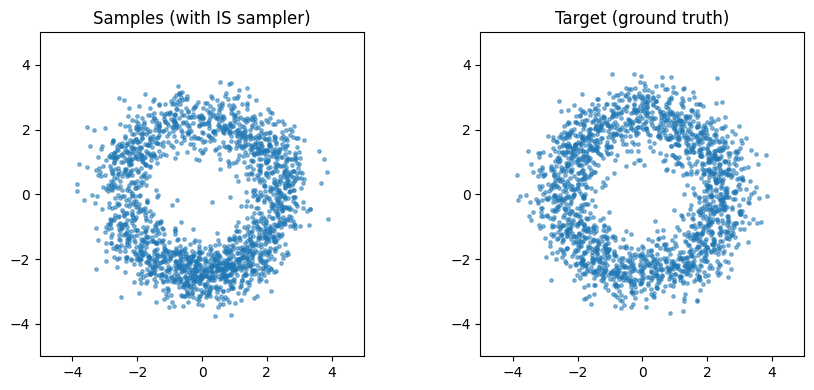

In [90]:
samples_is = langevin_sample(f_theta_is)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, pts, title in zip(axes,
    [samples_is, data],
    ['Samples (with IS sampler)', 'Target (ground truth)']):
    ax.scatter(pts[:, 0], pts[:, 1], s=6, alpha=0.5)
    ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
    ax.set_aspect('equal'); ax.set_title(title)
plt.tight_layout()
plt.show()